# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This playbook translates our Random Forest model probabilities into a prioritized queue of human-readable actions. The model observes historical decay patterns and flags pages that show high risk of traffic loss based on staleness and visibility.

**The Recommended Actions (Archetype Mapping):**
1. **`refresh`**: The default action for pages flagged as `stale_visible_page` or `page_one_decay_risk`. The content is old and losing its competitive edge on high-value SERPs.
2. **`expand_and_refresh`**: Assigned to the `thin_visible_page` archetype. The page is getting impressions but lacks the word count/depth of its competitors.
3. **`refresh_and_review_ctr`**: Assigned to the `low_ctr_visible_page` archetype. The page ranks well and gets impressions, but users aren't clicking. The Title/Meta Description needs immediate review.
4. **`monitor`**: Assigned to `general_refresh_review`. Pages with low risk probabilities that do not currently require editorial intervention.

## 2. Intended use and limits

**Intended Use:**
This playbook is a **decision-support tool** for SEO editors and content managers. It acts as a triage system, ranking thousands of URLs to surface the top 50-100 pages that require manual editorial review each week to prevent traffic decay.

**Strict Limitations (What the data cannot say):**
- **Observational, not Causal:** The model identifies pages where staleness is *associated with* decay. It does not prove that simply updating the timestamp will cause rankings to recover.
- **Lacks Intent Awareness:** The model cannot read the actual text. It does not know if a page is an evergreen definition (which rarely needs updates) or a news article (which decays rapidly).
- **Lacks Competitor Context:** The model does not know if a competitor just published a 5,000-word definitive guide that is stealing our clicks.

## 3. Human review + the no-go list

Every URL flagged in the top 100 must pass human review before resources are spent updating it.

**Human Review Checklist:**
1. Is this topic genuinely evergreen (e.g., "When was the Declaration of Independence signed?") where staleness doesn't matter?
2. Did the SERP layout change? (Did Google add a giant featured snippet that explains the CTR drop?)
3. Did a sibling page on our own domain absorb the traffic (URL consolidation/cannibalization)?

**The NO-GO List (What should NEVER be automated):**
- ❌ **Automated Content Rewriting:** Never pipe these flagged URLs directly into an LLM to auto-rewrite and publish without human editing.
- ❌ **Automated Deletion:** Never automatically delete or redirect a "decaying" page based solely on this score.
- ❌ **Performance Evaluation:** Never use this decay score to evaluate or penalize the original author of the content.

## 4. Monitoring / retrain triggers

Machine learning models degrade over time. We will monitor the following triggers to know when this playbook's recommendations have gone stale:

1. **Performance Drift:** If the `Precision@20` of the model's predictions on new holdout data drops below the naive base rate for two consecutive months.
2. **Feature Drift:** If the underlying distribution of a core feature changes massively (e.g., an engineering bug accidentally resets all `days_since_last_update` timestamps to 0 across the CMS).
3. **Exogenous Shocks:** Immediately following any confirmed "Google Core Algorithm Update," as the ranking rules and SERP layouts often shift dramatically, requiring a new baseline.

## 5. Exports for the paper

Below, we run the validated Random Forest model, attach the playbook reason codes/actions, and export the queue to `work/outputs/action_playbook_queue.csv`. We also export a summary figure to `work/figures/top_500_actions.png`.

✅ Saved prioritized playbook queue to work/outputs/action_playbook_queue.csv (30,000 rows)
✅ Saved paper figure to work/figures/top_500_actions.png


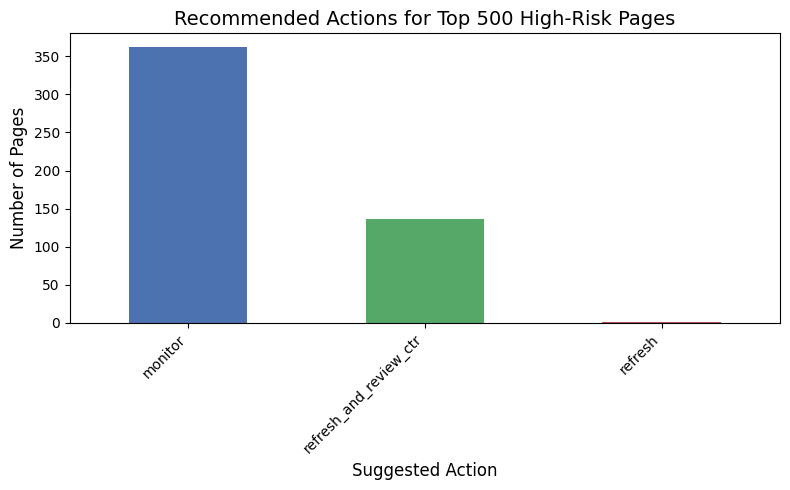

In [1]:
import os, sys, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

IN_COLAB = "google.colab" in sys.modules
REPO_DIR = "flyrank-seo-ml-pipeline"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/ak8x6/flyrank-seo-ml-pipeline", REPO_DIR], check=True)
    os.chdir(REPO_DIR)
elif os.path.basename(os.getcwd()) in ("notebooks", "work"):
    os.chdir(os.path.join("..", ".."))

df = pd.read_csv("data/raw/content_refresh_anonymized.csv").fillna(0)
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)

# 1. Re-train the validated Random Forest
features = ["impressions_90d", "days_since_last_update", "avg_position", "word_count", "ctr"]
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(df[features], df["is_declining_label"])

# 2. Generate risk probabilities and ranks
df["rf_risk_probability"] = rf.predict_proba(df[features])[:, 1]
df["playbook_priority_rank"] = df["rf_risk_probability"].rank(method="first", ascending=False).astype(int)

# 3. Assign Playbook Actions and Reason Codes
def assign_playbook(row):
    reasons = []
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_visible_page")
    if row["word_count"] > 0 and row["word_count"] < 1200 and row["impressions_90d"] >= 250:
        reasons.append("thin_visible_page")
    if 0 < row["avg_position"] <= 10 and row["days_since_last_update"] >= 180:
        reasons.append("page_one_decay_risk")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        reasons.append("low_ctr_visible_page")
    if not reasons:
        reasons.append("general_refresh_review")

    reason_str = "|".join(reasons)

    action = "monitor"
    if "thin_visible_page" in reasons:
        action = "expand_and_refresh"
    elif "low_ctr_visible_page" in reasons:
        action = "refresh_and_review_ctr"
    elif "stale_visible_page" in reasons or "page_one_decay_risk" in reasons:
        action = "refresh"

    return pd.Series([reason_str, action])

df[["reason_codes", "suggested_action"]] = df.apply(assign_playbook, axis=1)

# 4. Sort and Export CSV
df_playbook = df.sort_values("playbook_priority_rank").reset_index(drop=True)
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

csv_path = "work/outputs/action_playbook_queue.csv"
df_playbook.to_csv(csv_path, index=False)
print(f"✅ Saved prioritized playbook queue to {csv_path} ({len(df_playbook):,} rows)")

# 5. Generate and Export Figure for the Research Paper
action_counts = df_playbook.head(500)["suggested_action"].value_counts()
plt.figure(figsize=(8, 5))
ax = action_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Recommended Actions for Top 500 High-Risk Pages", fontsize=14)
plt.xlabel("Suggested Action", fontsize=12)
plt.ylabel("Number of Pages", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = "work/figures/top_500_actions.png"
plt.savefig(fig_path, dpi=300)
print(f"✅ Saved paper figure to {fig_path}")

## 6. Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.